## Evaluation Report

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from PIL import Image

In [5]:
class CMPFacadeDataset(Dataset):
    def __init__(self, image_dir, annot_dir, transform=None, resize_size=(512, 512)):
        self.image_dir = image_dir
        self.annot_dir = annot_dir
        self.transform = transform
        self.resize_size = resize_size

        image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".png")])
        annot_files = sorted([f for f in os.listdir(annot_dir) if f.endswith(".png")])

        self.image_files, self.annot_files = [], []
        for img_file in image_files:
            img_idx = img_file.replace("image_", "").replace(".png", "")
            annot_file = f"annotation_{img_idx}.png"
            if annot_file in annot_files:
                self.image_files.append(img_file)
                self.annot_files.append(annot_file)
            else:
                print(f"Warning: No matching annotation for {img_file}")

        if not self.image_files:
            raise ValueError("No image-annotation pairs found.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        annot_path = os.path.join(self.annot_dir, self.annot_files[idx])

        # Load and preprocess image with pencil sketch
        image = Image.open(img_path).convert("RGB")
        # image = pencil_sketch(image)  # Apply pencil sketch
        annotation = Image.open(annot_path)

        # Resize
        image = image.resize(self.resize_size, Image.Resampling.LANCZOS)
        annotation = annotation.resize(self.resize_size, Image.Resampling.NEAREST)

        # Convert to numpy and then to tensor
        image = np.array(image)
        annotation = np.array(annotation)
        annotation = np.clip(annotation, 0, 11)

        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        annotation = torch.from_numpy(annotation).long()

        if self.transform:
            image = self.transform(image)

        return image, annotation

In [6]:
# --- Paths ---
root_dir = "../data/nelissen_dataset"
image_root = os.path.join(root_dir, "images", "test")
mask_root = os.path.join(root_dir, "annotations", "test")

# --- Dataset and DataLoader ---
test_dataset = CMPFacadeDataset(image_root, mask_root, resize_size=(512, 512))
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [9]:
# --- Load Model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=False, aux_loss=True)
model.classifier[4] = nn.Conv2d(256, 12, kernel_size=(1, 1))
model.load_state_dict(torch.load("deeplabv3_best_model.pth", map_location=device))
model = model.to(device)
model.eval()

c:\dev_projects_pc\facade-analysis-ai\.venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\dev_projects_pc\facade-analysis-ai\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [11]:
# Flatten all predictions and labels
all_preds = np.concatenate([p.flatten() for p in all_preds])
all_labels = np.concatenate([l.flatten() for l in all_labels])

In [12]:
# --- Classification Report ---
print("Classification Report:")
print(classification_report(all_labels, all_preds, labels=list(range(12))))

Classification Report:


c:\dev_projects_pc\facade-analysis-ai\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\dev_projects_pc\facade-analysis-ai\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\dev_projects_pc\facade-analysis-ai\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

              precision    recall  f1-score   support

           0       0.88      0.94      0.91    653241
           1       0.93      0.93      0.93   2283817
           2       0.84      0.93      0.88    153548
           3       0.91      0.85      0.88    841554
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0

    accuracy                           0.92   3932160
   macro avg       0.30      0.30      0.30   3932160
weighted avg       0.92      0.92      0.92   3932160



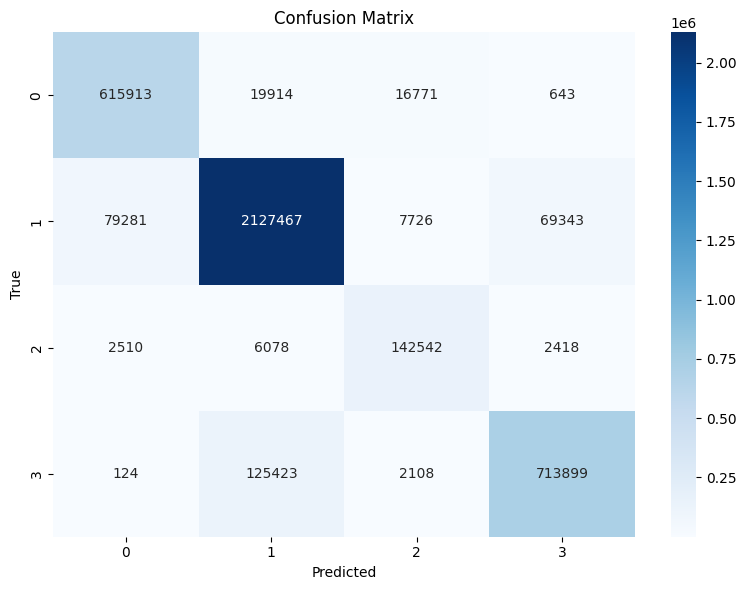

In [14]:
# --- Confusion Matrix ---
conf_mat = confusion_matrix(all_labels, all_preds, labels=list(range(4)))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(4), yticklabels=range(4))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

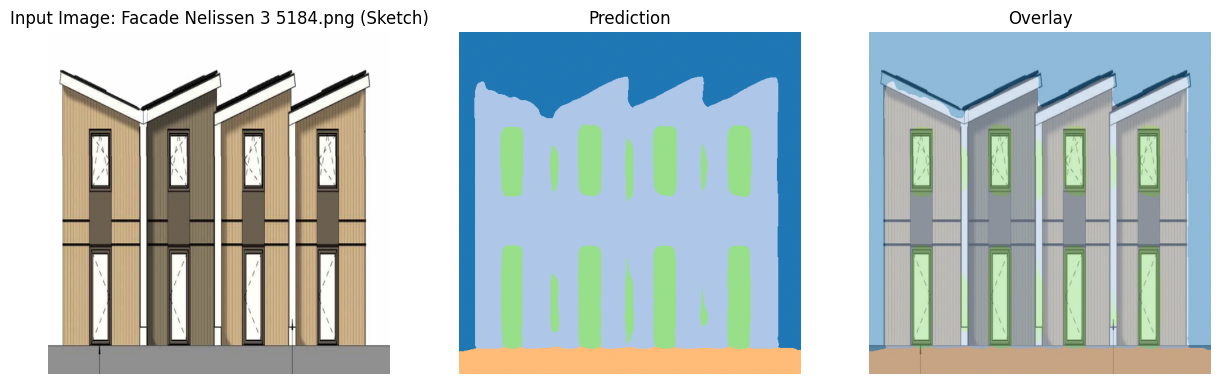

In [18]:
# Specify the path to the image
image_path = "../data/dump/Facade Nelissen 3 5184.png"

# Load and preprocess the image
image = Image.open(image_path).convert("RGB")
# image = pencil_sketch(image)  # Apply pencil sketch
resize_size = (512, 512)
image = image.resize(resize_size, Image.Resampling.LANCZOS)
image_np = np.array(image)  # Keep the sketched image for overlay
image = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0
image = image.unsqueeze(0).to(device)

# Perform inference
model.eval()
with torch.no_grad():
    output = model(image)['out']
    prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

# Visualize the input image, prediction, and overlay
plt.figure(figsize=(15, 5))

# Input Image
plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title(f"Input Image: {os.path.basename(image_path)} (Sketch)")
plt.axis("off")

# Prediction
plt.subplot(1, 3, 2)
plt.imshow(prediction, cmap="tab20", vmin=0, vmax=11)
plt.title("Prediction")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(image_np)
plt.imshow(prediction, cmap="tab20", vmin=0, vmax=11, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()